In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/howonmjeong/3-service-satisfaction/service_survey.csv
/kaggle/input/datasets/howonmjeong/3-service-satisfaction/answer_importance_rank.csv


In [2]:
path = '/kaggle/input/datasets/howonmjeong/3-service-satisfaction/'
df = pd.read_csv(path+'service_survey.csv')

In [3]:
df.head()

,soldier_id,leadership_score,facility_score,meal_score,rest_time_score,overall_satisfaction
0,S001,3.4,9.0,8.2,3.1,4.4
1,S002,7.1,4.1,1.9,6.3,6.0
2,S003,5.7,9.2,7.3,5.2,6.2
3,S004,5.0,4.4,6.2,8.4,5.4
4,S005,4.8,2.5,7.4,8.3,5.7


In [4]:
df.isnull().sum()

soldier_id               0
leadership_score         0
facility_score          10
meal_score              20
rest_time_score          0
overall_satisfaction     0
dtype: int64

In [5]:
df.describe()

,leadership_score,facility_score,meal_score,rest_time_score,overall_satisfaction
count,500.000000,490.000000,480.000000,500.000000,500.000000
mean,6.190000,6.373878,5.528750,5.348400,5.544800
std,4.765287,2.293792,2.627335,2.618452,1.452161
min,-3.000000,2.000000,1.000000,-1.000000,2.100000
25%,4.100000,4.400000,3.300000,3.075000,4.500000
50%,6.000000,6.600000,5.550000,5.100000,5.550000
75%,7.925000,8.300000,7.800000,7.525000,6.500000
max,99.000000,10.000000,10.000000,12.500000,9.700000


In [6]:
tofill = ['facility_score', 'meal_score']
df[tofill] = df[tofill].fillna(df[tofill].median())

In [7]:
df.isnull().sum()

soldier_id              0
leadership_score        0
facility_score          0
meal_score              0
rest_time_score         0
overall_satisfaction    0
dtype: int64

In [8]:
ok = (df['leadership_score'].between(-5, 10))
cleaned = df[ok].copy()
cleaned.describe()

,leadership_score,facility_score,meal_score,rest_time_score,overall_satisfaction
count,498.000000,498.000000,498.000000,498.000000,498.000000
mean,5.985944,6.368876,5.533936,5.344378,5.542771
std,2.295662,2.270459,2.577704,2.620316,1.454445
min,-3.000000,2.000000,1.000000,-1.000000,2.100000
25%,4.100000,4.400000,3.400000,3.025000,4.500000
50%,6.000000,6.600000,5.550000,5.100000,5.500000
75%,7.900000,8.275000,7.700000,7.500000,6.500000
max,10.000000,10.000000,10.000000,12.500000,9.700000


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

X = cleaned.drop(columns=['soldier_id', 'overall_satisfaction'])
y = cleaned['overall_satisfaction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [11]:
y_pred = model.predict(X_test)

import numpy as np

print(np.sqrt(mean_squared_error(y_test, y_pred)))

0.5719947464793707


In [12]:
df_result = df.loc[y_test.index, ['soldier_id']].copy()
df_result['actual'] = y_test.values
df_result['predicted'] = y_pred
df_result.head()

,soldier_id,actual,predicted
489,S490,3.6,3.163
73,S074,8.4,7.401
231,S232,4.8,4.244
175,S176,3.1,3.147
237,S238,5.4,5.671


In [13]:
importances = model.feature_importances_
feature_names = X.columns
sorted_idx = np.argsort(importances)[::-1]

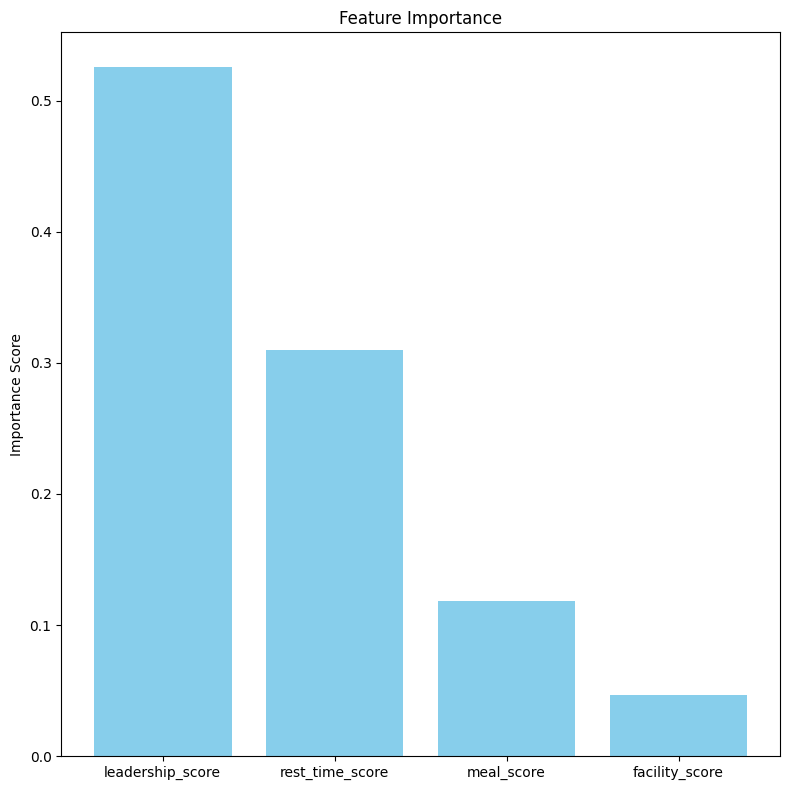

In [14]:
plt.figure(figsize=(8,8))
plt.bar([feature_names[i] for i in sorted_idx], importances[sorted_idx], color="skyblue")
plt.title('Feature Importance')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

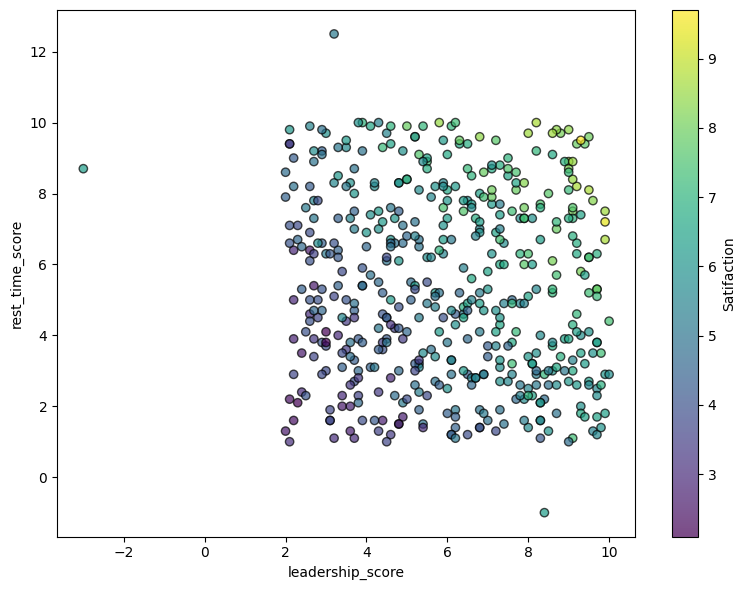

In [15]:
top2_features = [feature_names[i] for i in sorted_idx[:2]]
plt.figure(figsize=(8,6))
plt.scatter(X[top2_features[0]], X[top2_features[1]], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
plt.colorbar(label='Satifaction')
plt.xlabel(top2_features[0])
plt.ylabel(top2_features[1])
plt.tight_layout()
plt.show()